Imports

In [2]:
import torch
import torchvision
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.io import read_image
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import os
from datetime import datetime
from PIL import Image
from diffusers import UNet2DModel, DDPMScheduler

import torchvision.utils as vutils
torchvision.disable_beta_transforms_warning()

device = torch.device("cuda")
print(f"Using device: {device}")

Using device: cuda


Custom Dataset Class

In [3]:
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = [item for item in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir,item))]
        self.image_paths = []
        self.labels = []
        
        # Collect image file paths and corresponding labels
        for label in self.classes:
            class_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(class_dir):
                self.image_paths.append(os.path.join(class_dir, img_name))
                self.labels.append(self.classes.index(label))  # Assign numeric labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")  # Load the image
        # image = image.float() / 255.0

        if self.transform:
            image = self.transform(image)

        label = int(self.labels[idx])       # Get the label
        

        
        return image, label

Transform

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor(),           # Convert images to PyTorch tensors
])

Dataset

53905


(-0.5, 1041.5, 131.5, -0.5)

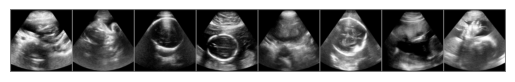

In [9]:
# Specify the path to your dataset
root_dir = '/mnt/raid/home/ajarry/data/trainer'
# train_dir = os.path.join(root_dir,"temp_train/")
# val_dir = os.path.join(root_dir,"temp_val/")

data_dir = '/mnt/famli_netapp_shared/C1_ML_Analysis/famli_ml_lists/AnalysisLists/East/datasets'
train_dir = os.path.join(data_dir, 'frame_C2_bfly_Head_ordinal_boundary/train/')
val_dir =  os.path.join(root_dir,"temp_train")

# Create dataset instance
# custom_dataset = CustomImageDataset(root_dir=root_dir, transform=transform)
train_dataset = CustomImageDataset(root_dir=train_dir,transform=transform)
val_dataset = CustomImageDataset(root_dir=val_dir,transform=transform)

# View some examples
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
print(train_dataloader.__len__())
x, y = next(iter(train_dataloader))

plt.imshow(torchvision.utils.make_grid(x)[0], cmap='gray')
plt.axis('off')

Corruption Method

In [5]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1,1,1,1)  # Sort shape so broadcasting works
    return x * (1 - amount) + noise * amount

torch.Size([8, 3, 128, 128])


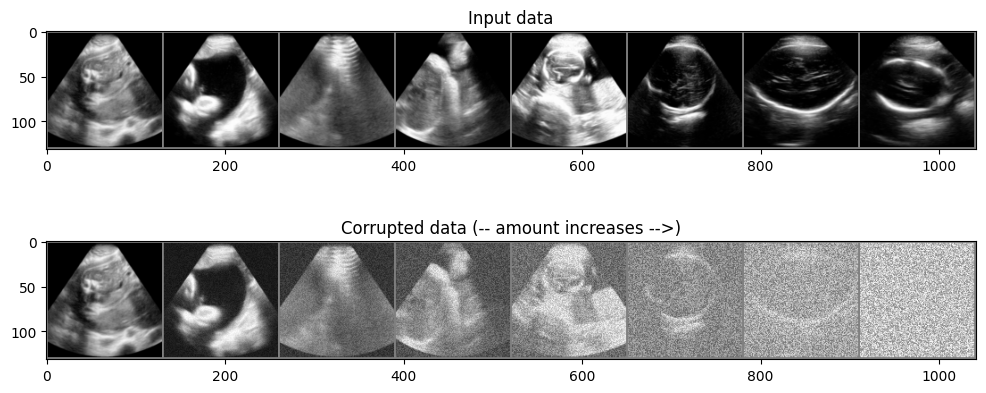

In [6]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="gray")

# Adding noise
amount = torch.linspace(0, 1, x.shape[0])  # Lft to right -> more corruption
noised_x = corrupt(x, amount)

print(x.shape)
# Plotting the noised version
axs[1].set_title("Corrupted data (-- amount increases -->)")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap="gray")

Basic UNET Model

In [7]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation."""

    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.ReLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection
                x = self.downscale(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.up_layers):
            if i > 0:  # For all except the first up layer
                x = self.upscale(x)  # Upscale
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x

Training

Finished epoch 0. Average loss for this epoch: 00nan. Average validation loss: 0.000000


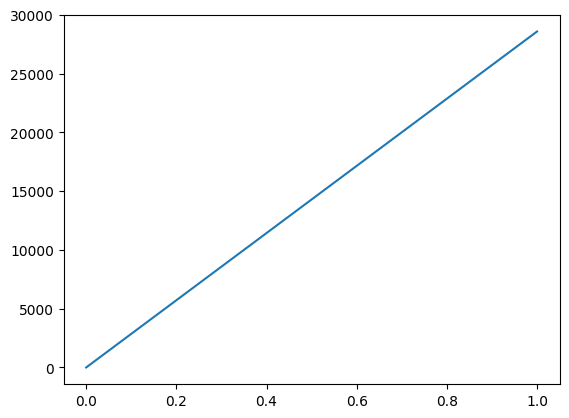

In [8]:
# Dataloader (you can mess with batch size)
batch_size = 32
num_workers = 4
train_dataloader = DataLoader(train_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size,num_workers=num_workers, shuffle=True)
scheduler = DDIMScheduler(num_train_timesteps=1000, beta_schedule="linear")

# How many runs through the data should we do?
n_epochs = 1

# Create the network
net = UNet2DModel()
net.to(device)


# Our loss function
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-0)

# Keeping a record of the losses for later viewing
train_losses = []
val_losses = []

# Define directory for saving checkpoints
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"outputs_v2/output_{timestamp}/"
os.makedirs(output_dir, exist_ok=True)

# The training loop
for epoch in range(n_epochs):

    net.train()
    
    for x, y in train_dataloader:
        # Get some data and prepare the corrupted version
        x = x.to(device)  # Data on the GPU
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (x.size(0),)).to(device)

        noise = torch.rand_like(x)
        noise = noise.to(device)

        # Get the model prediction
        noisy_images = scheduler.add_noise(x, noise, timesteps)
        pred = net(noisy_images, timesteps).sample

        # Calculate the loss
        train_loss = loss_fn(pred, x)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        train_loss.backward()
        opt.step()

        # Store the loss for later
        train_losses.append(train_loss.item())

    # Validation phase
    net.eval()
    with torch.no_grad():
        for x, y in val_dataloader:
            x = x.to(device)
            timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (x.size(0),), device=device)
            outputs = net(x,timesteps).sample
            val_loss = loss_fn(outputs,x)
            

    # Print our the average of the loss values for this epoch:
    avg_train_loss = sum(train_losses[-len(train_dataloader) :]) / len(train_dataloader)
    avg_val_loss = sum(val_losses) / len(val_dataloader)
    print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_train_loss:05f}. Average validation loss: {avg_val_loss:05f}")
    checkpoint_filename = f"checkpoint_epoch_{epoch+1}.pth"
    checkpoint_path = os.path.join(output_dir, checkpoint_filename)

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': net.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        }
    torch.save(checkpoint, checkpoint_path)

# View the loss curve
plt.plot(train_losses)
final_model_path = os.path.join(output_dir, "model.pth")
torch.save(net.state_dict(), final_model_path)


First Results

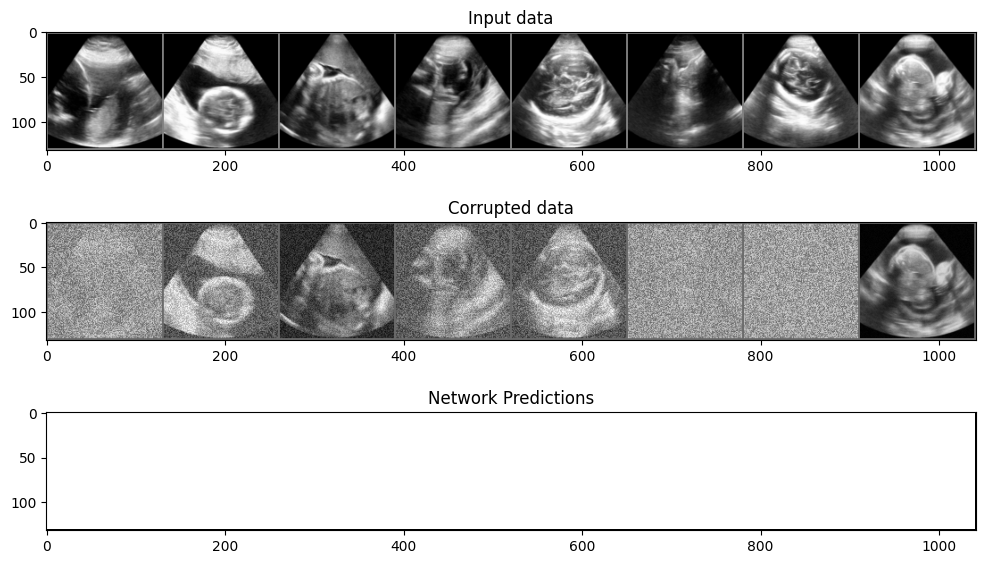

In [9]:
# @markdown Visualizing model predictions on noisy inputs:

# Fetch some data
x, y = next(iter(train_dataloader))
x = x[:8]  # Only using the first 8 for easy plotting
x = x.to(device)
noise = torch.rand_like(x)
noise = noise.to(device)
timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (x.size(0),)).to(device)

# Corrupt with a range of amounts
noisy_images = scheduler.add_noise(x, noise, timesteps)
noisy_images = noisy_images.to(device)

# Get the model predictions
with torch.no_grad():
    preds = net(noisy_images,timesteps).sample

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x.cpu())[0], cmap="gray")
axs[1].set_title("Corrupted data")
axs[1].imshow(torchvision.utils.make_grid(noisy_images.cpu())[0], cmap="gray")
axs[2].set_title("Network Predictions")
axs[2].imshow(torchvision.utils.make_grid(preds.cpu())[0], cmap="gray")


Sampling

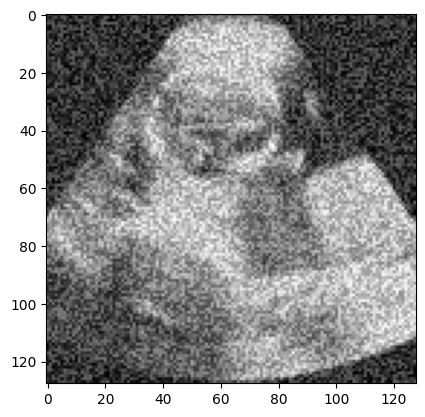

In [10]:
noisy_ultra = noised_x[4][0]
plt.imshow(noisy_ultra,cmap="gray")


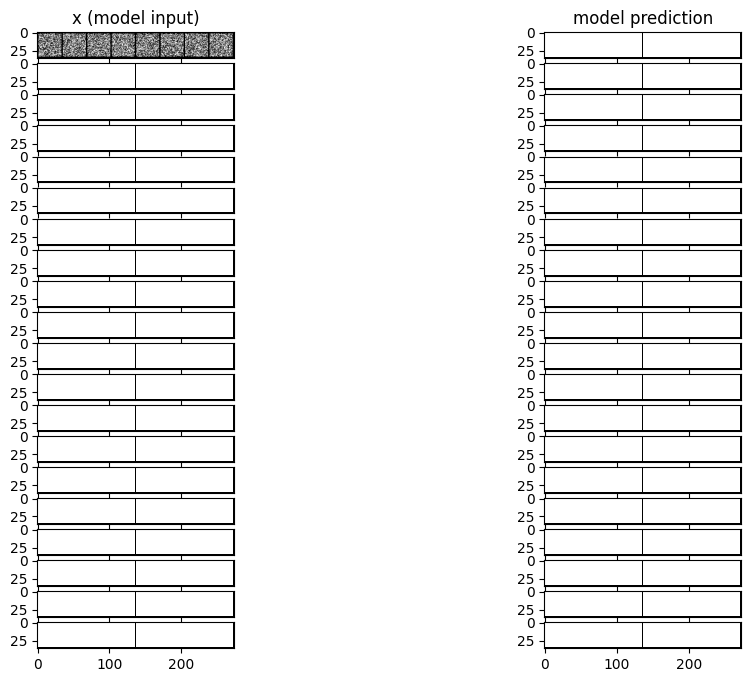

In [11]:
# @markdown Sampling strategy: Break the process into 5 steps and move 1/5'th of the way there each time:
n_steps = 20
x = torch.rand(8, 3, 32,32).to(device)  # Start from random
step_history = [x.detach().cpu()]
pred_output_history = []

for i in range(n_steps):
    with torch.no_grad():  # No need to track gradients during inference
        pred = net(x,timesteps).sample  # Predict the denoised x0
    pred_output_history.append(pred)  # Store model output for plotting
    mix_factor = 1 / (n_steps - i)  # How much we move towards the prediction
    x = x * (1 - mix_factor) + pred * mix_factor  # Move part of the way there
    step_history.append(x.detach().cpu())  # Store step for plotting

fig, axs = plt.subplots(n_steps, 2, figsize=(12, 8), sharex=True)
axs[0, 0].set_title("x (model input)")
axs[0, 1].set_title("model prediction")
for i in range(n_steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_history[i])[0].clip(0, 1), cmap="gray")
    axs[i, 1].imshow(torchvision.utils.make_grid(pred_output_history[i].cpu())[0].clip(0, 1), cmap="gray")


torch.Size([3, 128, 128])


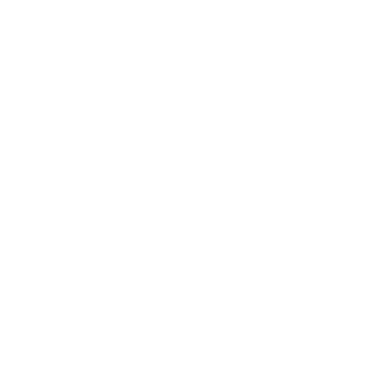

: 

In [12]:

num_inference_steps = 500
scheduler.set_timesteps(num_inference_steps)

initial_noise = torch.randn(1, 3, 128,128)  # Adjust shape as needed
x_t = initial_noise  # Start with random noise


x_t = x_t.to(device)
net = net.to(device)
timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (x_t.size(0),)).to(device)


for t in scheduler.timesteps:
    with torch.no_grad():
        # Get the model's prediction of noise at this step
        model_output = net(x_t,timesteps).sample  # Adjust for model's input format if needed
        # Update x_t to the denoised image for this timestep
        x_t = scheduler.step(model_output, t, x_t)[0]

# Normalize and move to CPU
x_t = x_t.detach().cpu()  # Ensure it's on the CPU and detached from computation graph
x_t = x_t.squeeze(0)  # Add batch dimension if not present
print(x_t.shape)

# Display the image
plt.imshow(x_t[0],cmap="gray")
plt.axis("off")  # Hide axes for cleaner display
plt.show()

